# Implementação do Adaline

In [ ]:
import numpy as np

class Adaline():
  def __init__(self, n_features:int, seed:int=42):
    np.random.seed(seed)
    self.pesos = np.random.rand(n_features + 1).astype(np.float32)

  def _adicionar_bias(self, X):
    '''Cria uma cópia dos dados com coluna extra de 1s'''
    X = np.array(X)
    uns = np.ones((X.shape[0], 1), dtype=np.float32)
    return np.hstack([X, uns])

  def _ativacao(self, u):
    '''Função de ativação do tipo degrau bipolar'''
    return 1 if u >= 0 else -1

  def _combinacao(self, X):
    return float(np.dot(X, self.pesos))

  def _forward(self, X):
      u = self._combinacao(X)
      return self._ativacao(u)

  def _erro_vetorial(self, y, U):
    '''Erro médio quadrático entre os vetores de amostra e potencial de ativação'''
    return (np.sum((y.ravel() - U) ** 2))/2

  def _erro_amostra(self, y_i, u):
    '''Erro médio quadrático entre uma amostra e um potencial de ativação'''
    return ((y_i - u) ** 2)/2

  def _taxa_erro(self, y, y_preds):
    return np.mean(y != y_preds)

  def _delta_batch(self, X, U, y, lr):
    erros = y - U
    self.pesos += lr * X.T.dot(erros) / len(U)

  def _delta_amostra(self, i, X_i, y_i, u, lr):
    erro = y_i - u
    self.pesos += lr * erro * X_i


  def train(self, X, y, epochs: int, lr: float, batch=True):
    '''
    Função de treinamento do adaline.
    Retorna vetor de erros absolutos e acurácias por época.
    '''
    X = self._adicionar_bias(np.array(X, dtype=np.float32))
    y = np.array(y).ravel()

    erros = []
    taxas_erro = []
    for _ in range(epochs):
      erro_epoca = 0

      if batch:
        U = np.array([self._combinacao(X[i]) for i in range(len(X))])
        erro_epoca = self._erro_vetorial(y, U)
        self._delta_batch(X, U, y, lr)

      else:
        for i in range(len(X)):
          u = self._combinacao(X[i])
          erro_epoca += self._erro_amostra(y[i], u)
          self._delta_amostra(i, X[i], y[i], u, lr)

      erros.append(erro_epoca)
      y_preds = np.array([self._forward(X[i]) for i in range(len(X))]) # uma forward pass no final da época para calcular a acurácia
      taxas_erro.append(self._taxa_erro(y, y_preds))

    return erros, taxas_erro

  def test(self, X, y):
    '''Função de teste do Adaline'''
    X = self._adicionar_bias(X)
    y = np.array(y).ravel()

    y_preds = np.array([
        self._forward(X[i])
        for i in range(len(X))
    ])
    return self._taxa_erro(y, y_preds)

  def get_pesos(self):
    return self.pesos

  def get_bias(self):
    return self.pesos[-1]

# Experimentos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def plotar_graficos(erros, acuracia_treino, acuracia_teste, ylim=None):
  plt.figure(figsize=(13, 6))
  plt.subplot(1, 2, 1)
  plt.plot(erros, label='Treino')
  plt.ylabel('Erro Médio Quadrádico')
  plt.xlabel('Épocas')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(acuracia_treino, label='Treino')
  plt.xlabel('Épocas')
  plt.ylabel('Erro de Classificação')
  plt.axhline(acuracia_teste, label='Teste', color='orange')
  plt.annotate(f'{acuracia_teste:.5f}', (len(acuracia_treino)/2, acuracia_teste)),
  if ylim:
    plt.ylim(ylim)
  plt.legend()
  plt.show()

## Dataset #1

In [ ]:
train1_path = "/content/train_dataset1.csv"
test1_path = "/content/test_dataset1.csv"

In [ ]:
X_train1 = pd.read_csv(train1_path, usecols=['x1', 'x2'])
y_train1 = pd.read_csv(train1_path, usecols=['label'])

X_test1 = pd.read_csv(test1_path, usecols=['x1', 'x2'])
y_test1 = pd.read_csv(test1_path, usecols=['label'])

In [ ]:
display(X_train1.head())
display(y_train1.head())

,x1,x2
0,0.254018,-0.402391
1,0.180883,0.510887
2,0.227152,0.467715
3,-0.122832,0.502635
4,0.437193,-0.579592


,label
0,-1
1,1
2,1
3,1
4,-1


### Batched

In [ ]:
adaline_batch1 = Adaline(2)
erros_batch1, taxa_erro_treino_batch1 = adaline_batch1.train(X_train1, y_train1, 100, 0.1, batch=True)
taxa_erro_teste_batch1 = adaline_batch1.test(X_test1, y_test1)

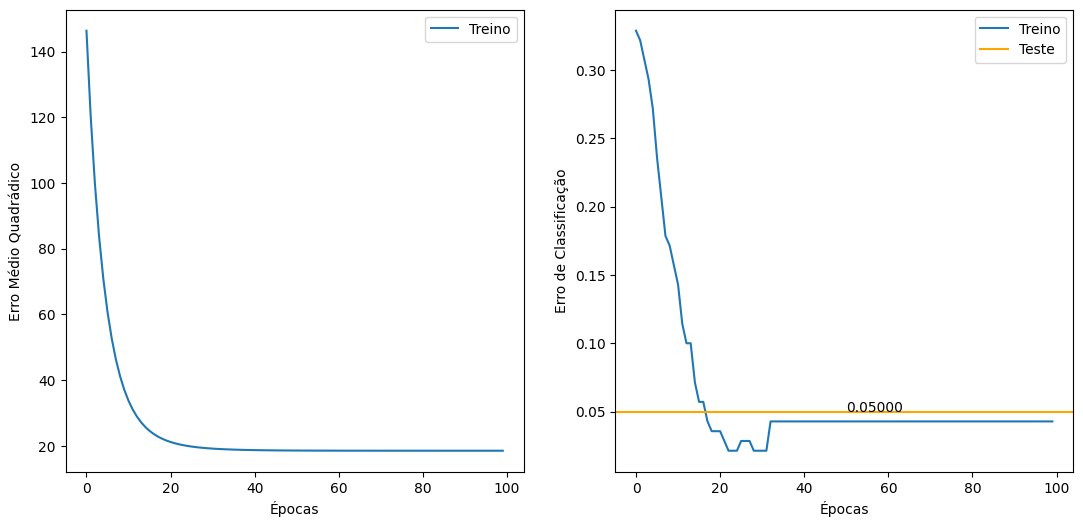

In [ ]:
plotar_graficos(erros_batch1, taxa_erro_treino_batch1, taxa_erro_teste_batch1)

### Por Amostra

In [ ]:
adaline1 = Adaline(2)
erros1, taxa_erro_treino1 = adaline1.train(X_train1, y_train1, 100, 0.1, batch=False)
taxa_erro_teste1 = adaline1.test(X_test1, y_test1)

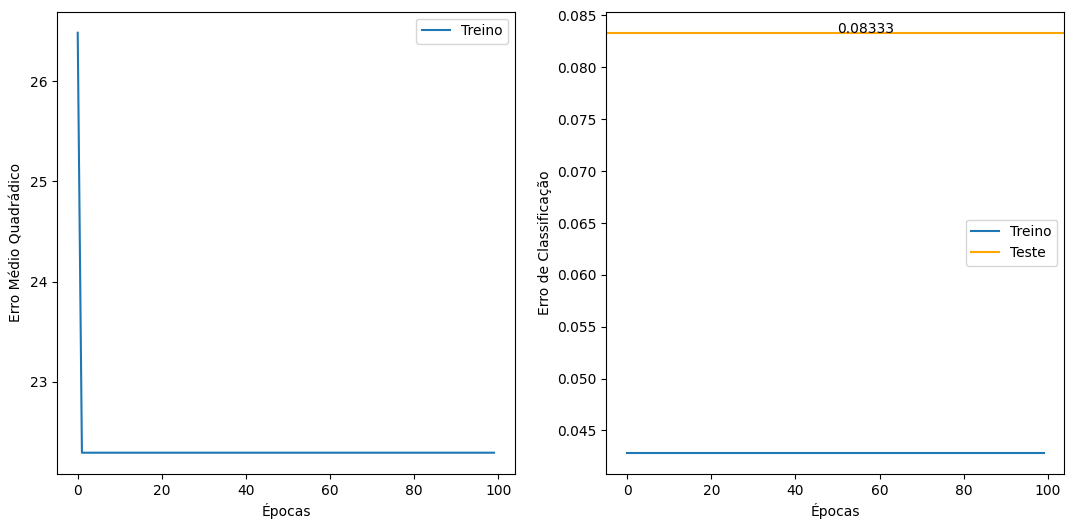

In [ ]:
plotar_graficos(erros1, taxa_erro_treino1, taxa_erro_teste1)

Percebe-se que o modo por amostra tem uma queda bem mais rápida e brusca do erro médio quadrático em comparação ao modo *batched*, com estagnação após poucas épocas, mas que o erro de classificaçao do teste tem um valor maior (~0.08 em comparação com ~0.05). Isso parece indicar que o processo de atualização de pesos ocorreu rápido demais no caso "por amostra" e ficou "preso", levando a uma generalização pior.


### Extra: Visualização

In [ ]:
def plot_fronteira(X, y, w_batch, w_amostra, titulo='Adaline — fronteira de decisão',
                   label_pos='Classe 1', label_neg='Classe -1',
                   classe_pos=1, classe_neg=-1):
    X = np.array(X)
    y = np.array(y).ravel()

    mask_pos = y == classe_pos
    mask_neg = y == classe_neg

    plt.figure(figsize=(7, 5))

    plt.scatter(X[mask_pos, 0], X[mask_pos, 1], c='steelblue', label=label_pos,
                alpha=0.7, edgecolors='white', linewidth=0.5)
    plt.scatter(X[mask_neg, 0], X[mask_neg, 1], c='coral', label=label_neg,
                alpha=0.7, edgecolors='white', linewidth=0.5)

    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)

    for w, label, style in [
        (w_batch,   'Fronteira (batch)',      'k--'),
        (w_amostra, 'Fronteira (por amostra)', 'g:'),
    ]:
        x2 = -(w[0] * x1 + w[2]) / w[1]
        plt.plot(x1, x2, style, linewidth=1.5, label=label)

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

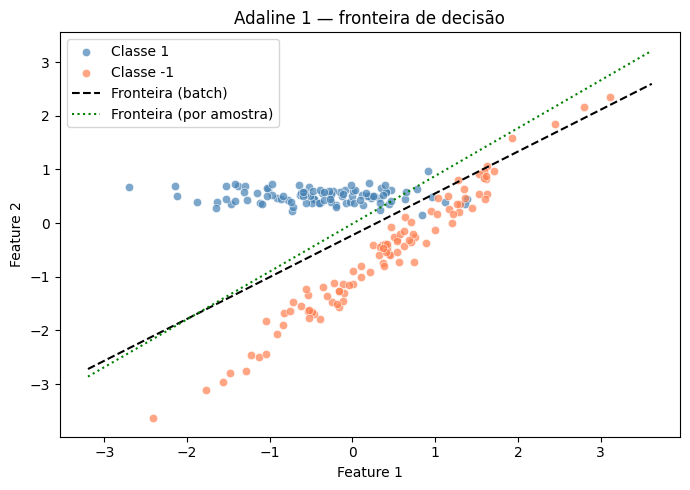

In [ ]:
X = np.append(X_train1.values, X_test1.values, axis=0)
y = np.append(y_train1['label'].values, y_test1['label'].values, axis=0)

plot_fronteira(X, y, adaline1.get_pesos(), adaline_batch1.get_pesos(), titulo='Adaline 1 — fronteira de decisão')

## Dataset #2

In [ ]:
train2_path = "/content/train_dataset2.csv"
test2_path = "/content/test_dataset2.csv"

In [ ]:
X_train2 = pd.read_csv(train2_path, usecols=['x1', 'x2'])
y_train2 = pd.read_csv(train2_path, usecols=['label'])

X_test2 = pd.read_csv(test2_path, usecols=['x1', 'x2'])
y_test2 = pd.read_csv(test2_path, usecols=['label'])

In [ ]:
display(X_train2.head())
display(y_train2.head())

,x1,x2
0,-0.882159,-0.511697
1,0.056971,0.101538
2,0.987759,-0.000616
3,1.108407,0.017528
4,-0.555163,0.770001


,label
0,-1
1,1
2,-1
3,-1
4,-1


### Batched

In [ ]:
adaline_batch2 = Adaline(2)
erros_batch2, taxa_erro_treino_batch2 = adaline_batch2.train(X_train2, y_train2, 100, 0.1, batch=True)
taxa_erro_teste_batch2 = adaline_batch2.test(X_test2, y_test2)

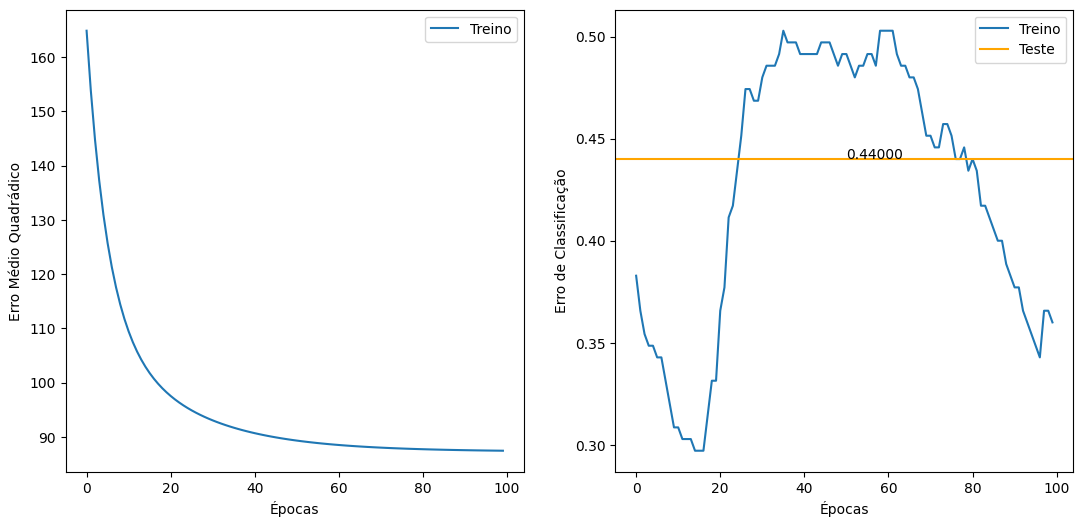

In [ ]:
plotar_graficos(erros_batch2, taxa_erro_treino_batch2, taxa_erro_teste_batch2)

### Por Amostra

In [ ]:
adaline2 = Adaline(2)
erros2, taxa_erro_treino2 = adaline2.train(X_train2, y_train2, 100, 0.1, batch=False)
taxa_erro_teste2 = adaline2.test(X_test2, y_test2)

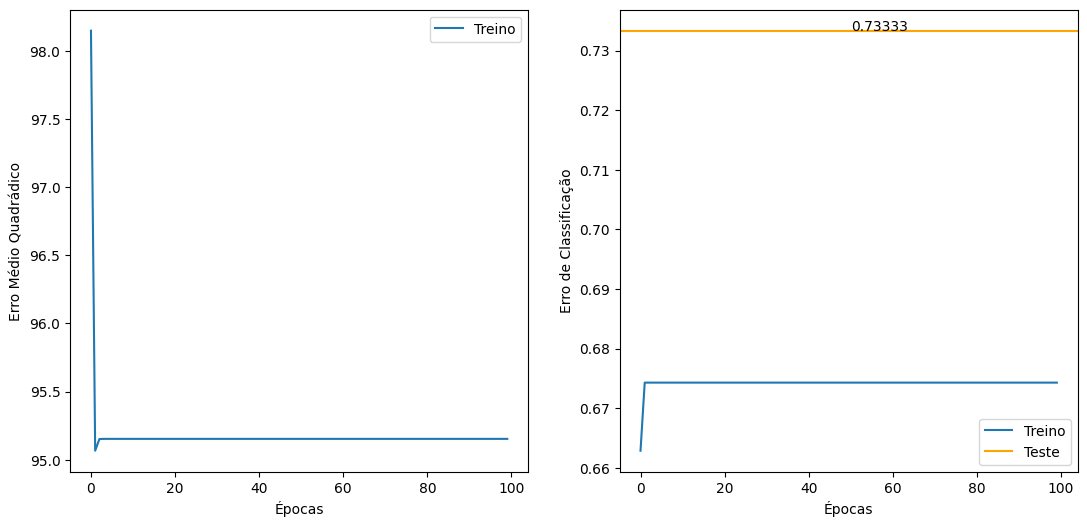

In [ ]:
plotar_graficos(erros2, taxa_erro_treino2, taxa_erro_teste2)

Como os dados não são linearmente separáveis, é de se esperar uma performance ruim. No entanto, o modo por amostra apresenta estagnação em um valor de erro mais elevado do que o modo por *batch*, tanto para erro médio quadrático quanto para taxa de erros, tanto em treino quanto em teste.

### Extra: Visualização

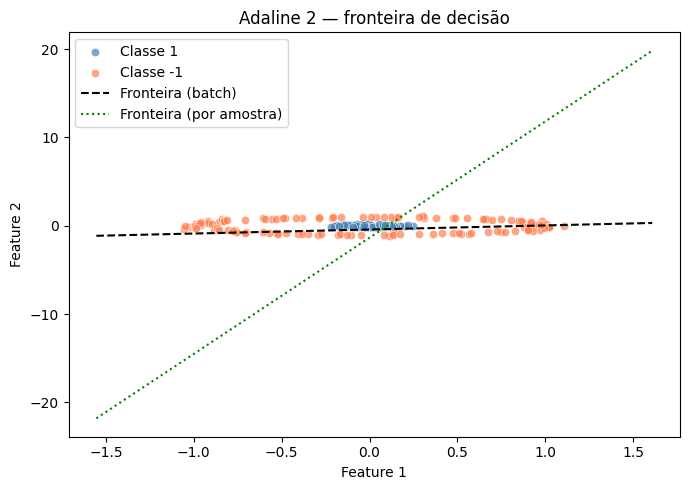

In [ ]:
X = np.append(X_train2.values, X_test2.values, axis=0)
y = np.append(y_train2['label'].values, y_test2['label'].values, axis=0)

plot_fronteira(X, y, adaline2.get_pesos(), adaline_batch2.get_pesos(), titulo='Adaline 2 — fronteira de decisão')

## Dataset #3

In [ ]:
train3_path = "/content/train_dataset3.csv"
test3_path = "/content/test_dataset3.csv"

In [ ]:
train3 = pd.read_csv(train3_path)
X_train3 = train3.drop(columns=['label'])
y_train3 = train3['label']

test3 = pd.read_csv(test3_path)
X_test3 = test3.drop(columns=['label'])
y_test3 = test3['label']

### Batched

Learning Rate: 0.1	 Épocas: 100


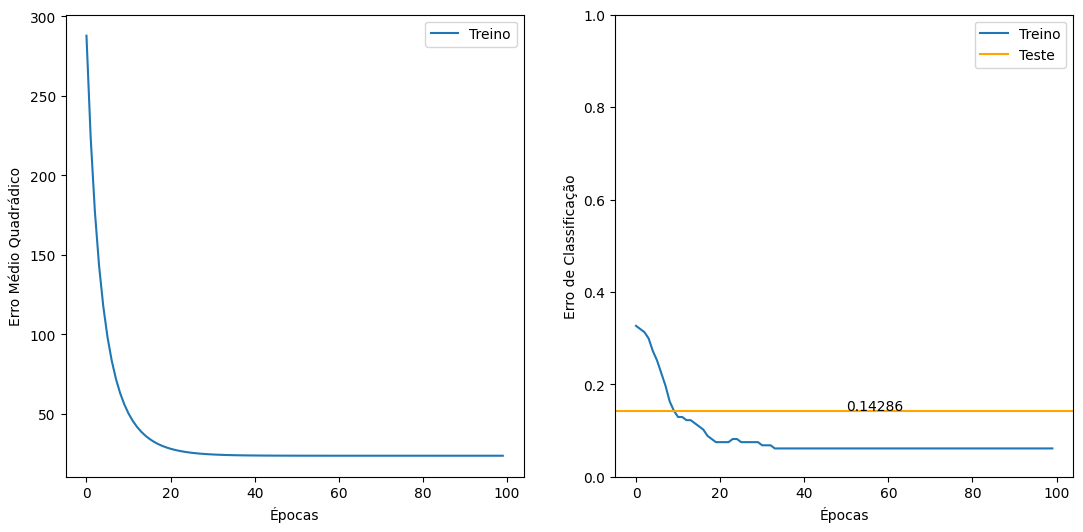

Learning Rate: 0.1	 Épocas: 200


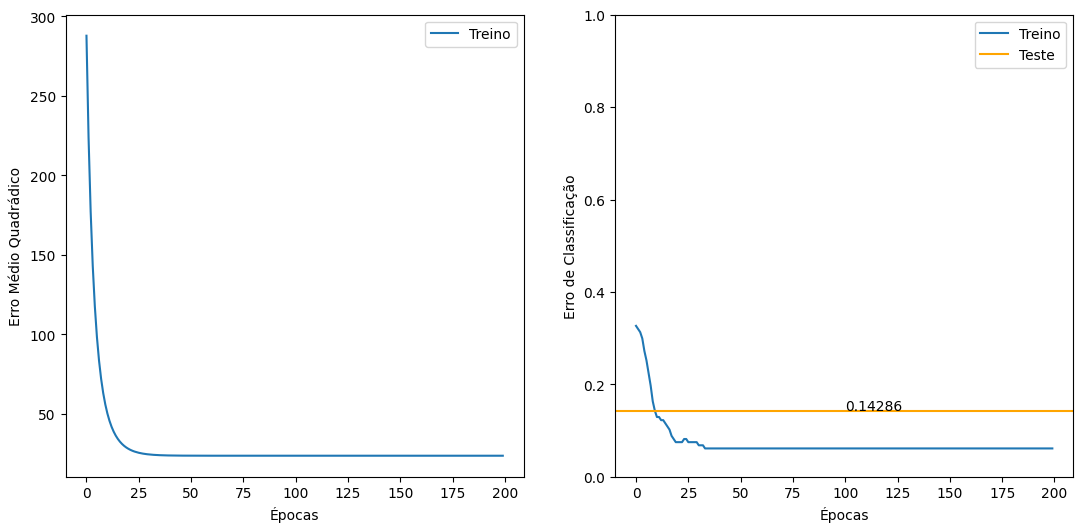

Learning Rate: 0.001	 Épocas: 100


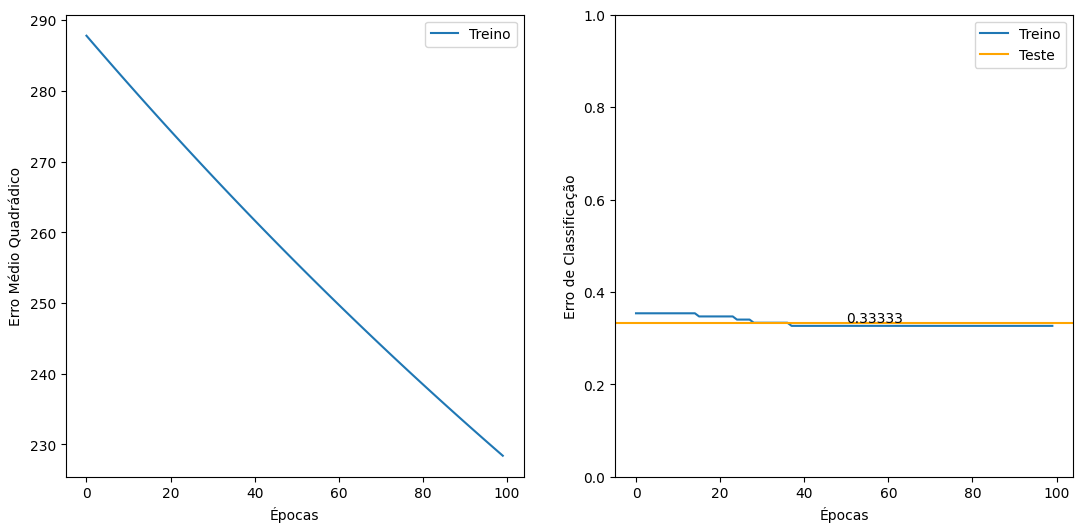

Learning Rate: 0.001	 Épocas: 200


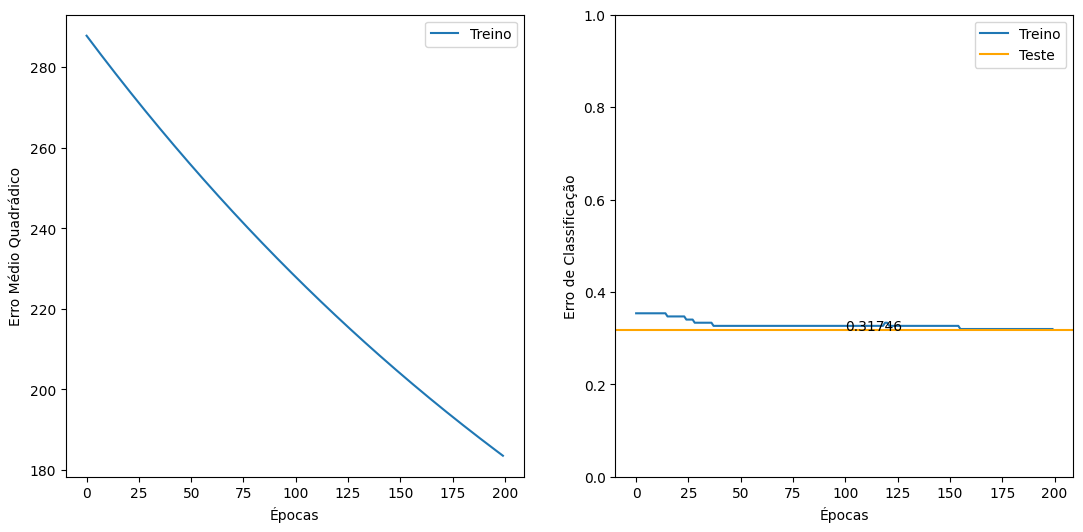

Learning Rate: 0.0001	 Épocas: 100


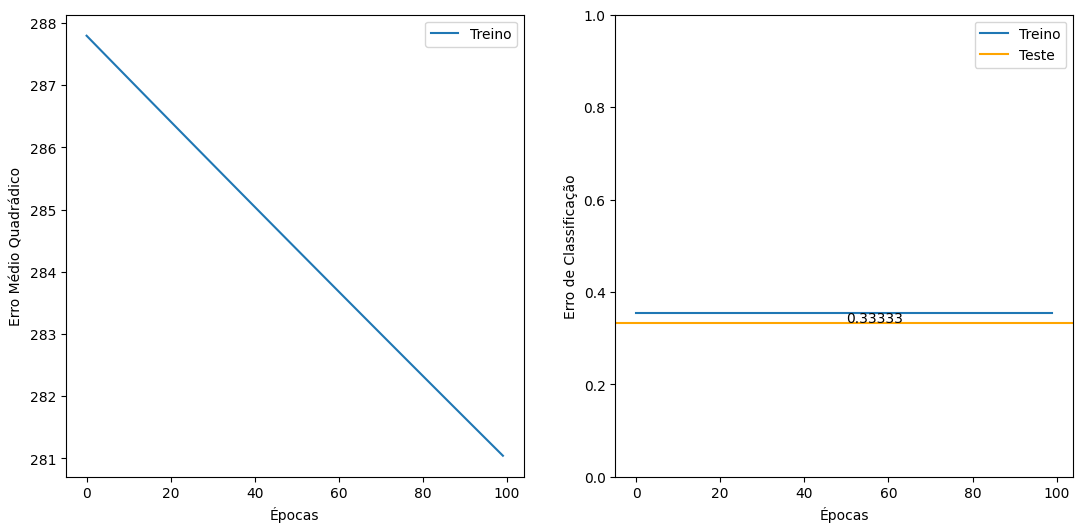

Learning Rate: 0.0001	 Épocas: 200


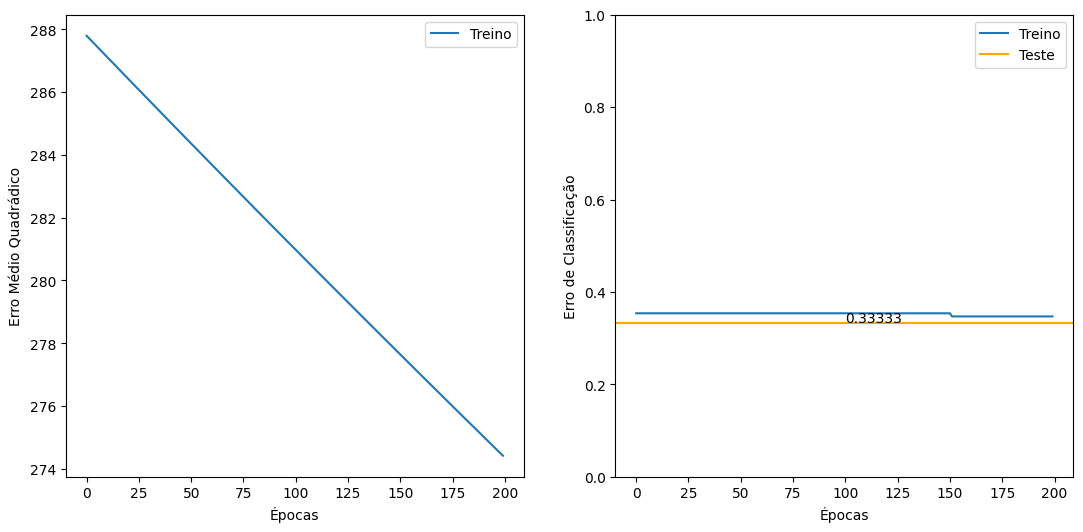

In [ ]:
best_hiperparametros_batch = None
best_taxa_erro_batch3 = float('inf')

for lr in [0.1, 0.001, 0.0001]:
  for ep in [100, 200]:
    adaline_batch3 = Adaline(10)
    erros_batch3, taxa_erro_treino_batch3 = adaline_batch3.train(X_train3, y_train3, ep, lr, batch=True)
    taxa_erro_teste_batch3 = adaline_batch3.test(X_test3, y_test3)

    if taxa_erro_teste_batch3 < best_taxa_erro_batch3:
      best_taxa_erro_batch3 = taxa_erro_teste_batch3
      best_hiperparametros_batch = (lr, ep)

    print(f"Learning Rate: {lr}\t Épocas: {ep}")
    plotar_graficos(erros_batch3, taxa_erro_treino_batch3, taxa_erro_teste_batch3, ylim = (0,1))

In [ ]:
print(f"Melhor taxa de erro: {best_taxa_erro_batch3}")
print(f"Melhor taxa de aprendizado: {best_hiperparametros_batch[0]}")
print(f"Melhor quantidade de épocas: {best_hiperparametros_batch[1]}")

Melhor taxa de erro: 0.14285714285714285
Melhor taxa de aprendizado: 0.1
Melhor quantidade de épocas: 100


Destaca-se que há combinações em que a taxa de erros do teste foi menor do que no treino, especificamente, as que tem *learning rate* de 0.0001, e a combinação de 0.001 e 200 épocas, sugerindo uma boa generalização.

Entretanto, esses valores de erro permanecem acima do melhor valor encontrado. De fato, a diminuição do learning rate e o aumento do número de épocas degradaram a performance do modo *batched*.

### Por Amostra

Learning Rate: 0.1	 Épocas: 100


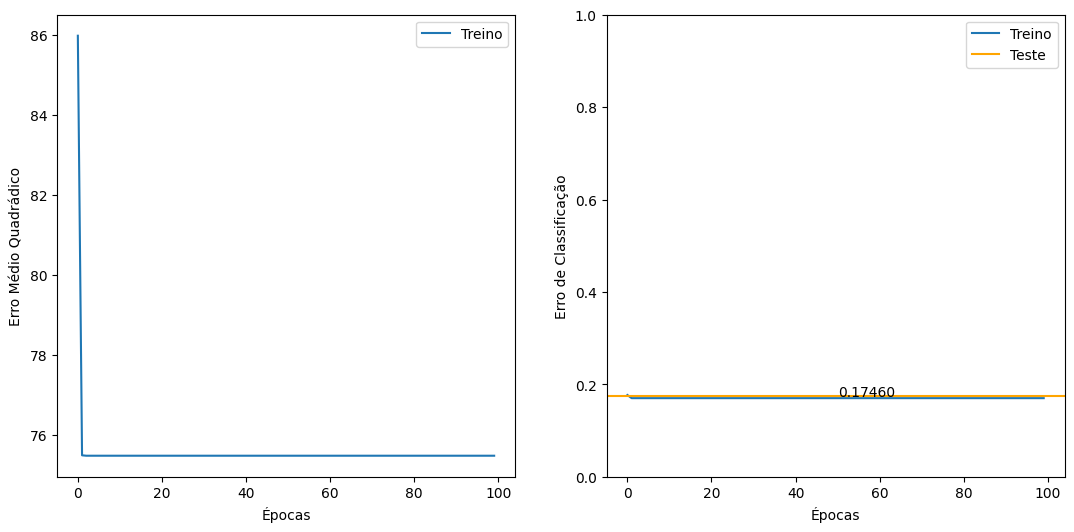

Learning Rate: 0.1	 Épocas: 200


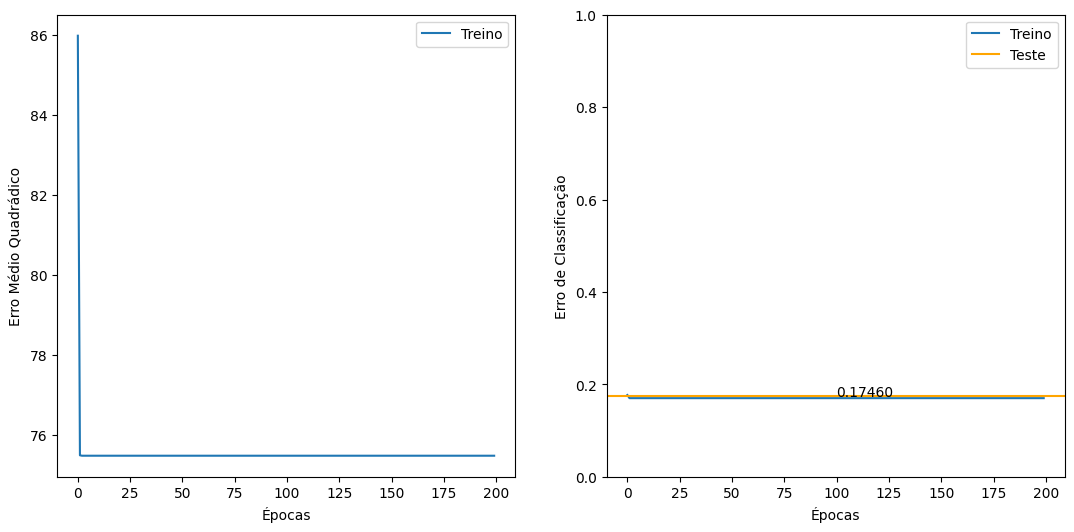

Learning Rate: 0.001	 Épocas: 100


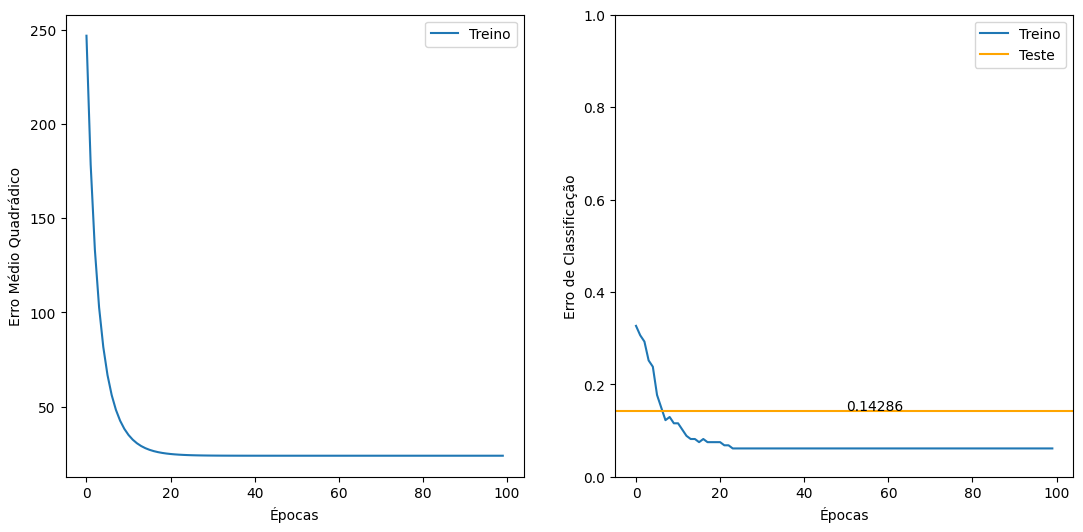

Learning Rate: 0.001	 Épocas: 200


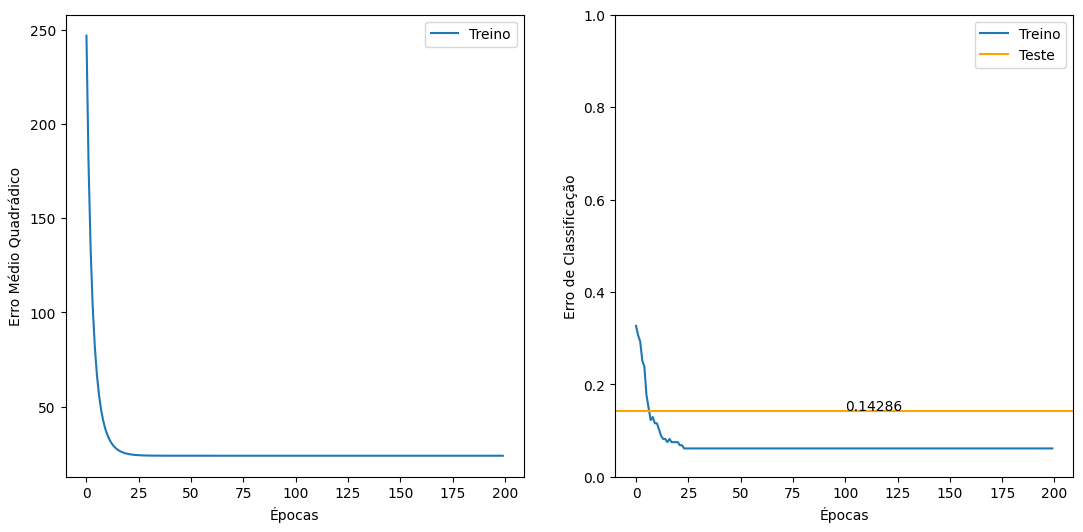

Learning Rate: 0.0001	 Épocas: 100


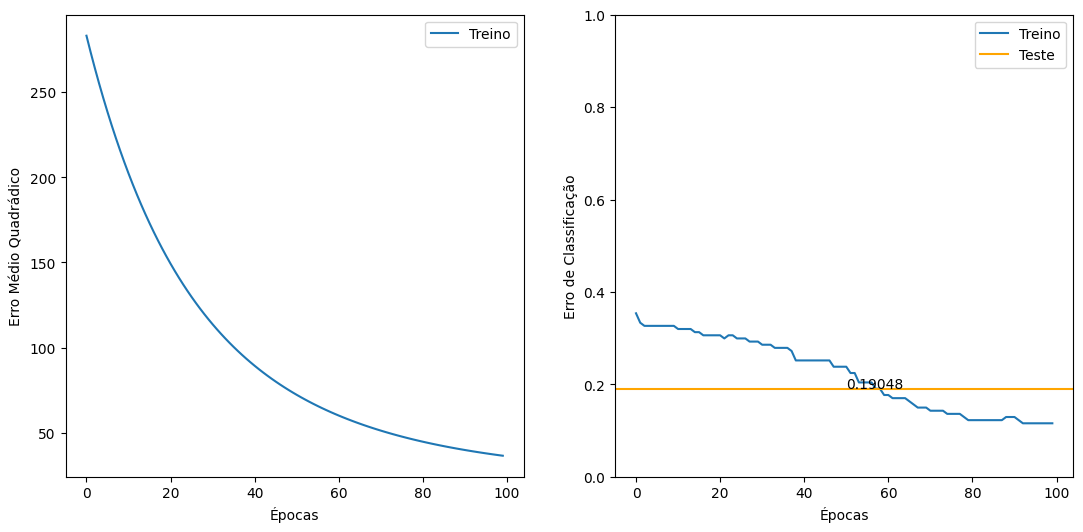

Learning Rate: 0.0001	 Épocas: 200


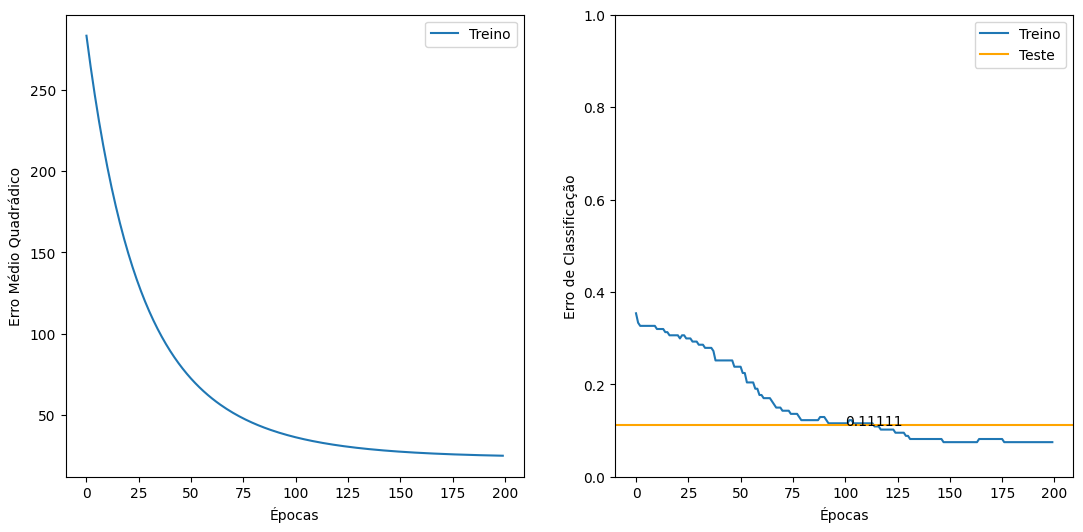

In [ ]:
best_hiperparametros = None
best_taxa_erro3 = float('inf')

for lr in [0.1, 0.001, 0.0001]:
  for ep in [100, 200]:
    adaline3 = Adaline(10)
    erros3, taxa_erro_treino3 = adaline3.train(X_train3, y_train3, ep, lr, batch=False)
    taxa_erro_teste3 = adaline3.test(X_test3, y_test3)

    if taxa_erro_teste3 < best_taxa_erro3:
      best_taxa_erro3 = taxa_erro_teste3
      best_hiperparametros = (lr, ep)

    print(f"Learning Rate: {lr}\t Épocas: {ep}")
    plotar_graficos(erros3, taxa_erro_treino3, taxa_erro_teste3, ylim = (0,1))

In [ ]:
print(f"Melhor taxa de erro: {best_taxa_erro3}")
print(f"Melhor taxa de aprendizado: {best_hiperparametros[0]}")
print(f"Melhor quantidade de épocas: {best_hiperparametros[1]}")

Melhor taxa de erro: 0.1111111111111111
Melhor taxa de aprendizado: 0.0001
Melhor quantidade de épocas: 200


Destaca-se que, no modo "por amostra", não houve erros de teste abaixo do erro final de treinamento. Isso indica que este modo tem menos potencial de generalização do que o por *batches*.

Entretanto, a menor taxa de erro encontrada "por amostra" foi menor do que a menor taxa no modo *batched*.

---
Considerando todos os testes feitos com o Dataset 3, há uma tendência para o modo *batched* ter um melhor desempenho para taxas de aprendizado maiores; particularmente, nota-se que o modo *batched* teve taxa de erro de teste em torno de 0.14 com um *learning rate* de 0.1, enquanto o modo "por amostra" teve um desempenho comparável com taxa de aprendizado de 0.001.

Isso está de acordo com a teoria estudada, já que a utilização de um *learning rate* menor para a atualização amostra por amostra é equiparável ao uso da média do gradiente que é feito no modo *batched*.


### Extra

A título de curiosidade, visualizações das combinações 2 a 2 das features e as respectivas projeções do hiperplano de decisão, tanto para o modo batched quanto por amostra.

In [ ]:
from itertools import combinations

def plot_todas_fronteiras(X, y, w_batch, w_amostra, feature_names=None,
                          titulo_base='Adaline',
                          classe_pos=1, classe_neg=-1,
                          label_pos='Classe 1', label_neg='Classe -1'):
    X = np.array(X)
    y = np.array(y).ravel()
    n_features = X.shape[1]

    if feature_names is None:
        feature_names = [f'Feature {i+1}' for i in range(n_features)]

    pares = list(combinations(range(n_features), 2))
    n_plots = len(pares)

    n_cols = 5
    n_rows = int(np.ceil(n_plots / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    mask_pos = y == classe_pos
    mask_neg = y == classe_neg

    fronteiras = [
        (w_batch,   'Fronteira (batch)',       'k--'),
        (w_amostra, 'Fronteira (por amostra)', 'g:'),
    ]

    for idx, (i, j) in enumerate(pares):
        ax = axes[idx]

        ax.scatter(X[mask_pos, i], X[mask_pos, j], c='steelblue', label=label_pos,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=30)
        ax.scatter(X[mask_neg, i], X[mask_neg, j], c='coral', label=label_neg,
                   alpha=0.7, edgecolors='white', linewidth=0.5, s=30)

        for w, label, style in fronteiras:
            if abs(w[j]) > 1e-6:
                xi_vals = np.linspace(X[:, i].min() - 0.5, X[:, i].max() + 0.5, 200)
                xj_vals = -(w[i] * xi_vals + w[-1]) / w[j]
                ax.plot(xi_vals, xj_vals, style, linewidth=1.2, label=label)
            else:
                ax.text(0.5, 0.5, f'w[j] ≈ 0\nsem fronteira\n({label})',
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=7, color='gray')

        ax.set_xlabel(feature_names[i], fontsize=9)
        ax.set_ylabel(feature_names[j], fontsize=9)
        ax.set_title(f'{feature_names[i]} × {feature_names[j]}', fontsize=9)
        ax.tick_params(labelsize=7)

    axes[0].legend(fontsize=7, loc='best')

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(titulo_base, fontsize=13, y=1)
    plt.tight_layout()
    plt.show()

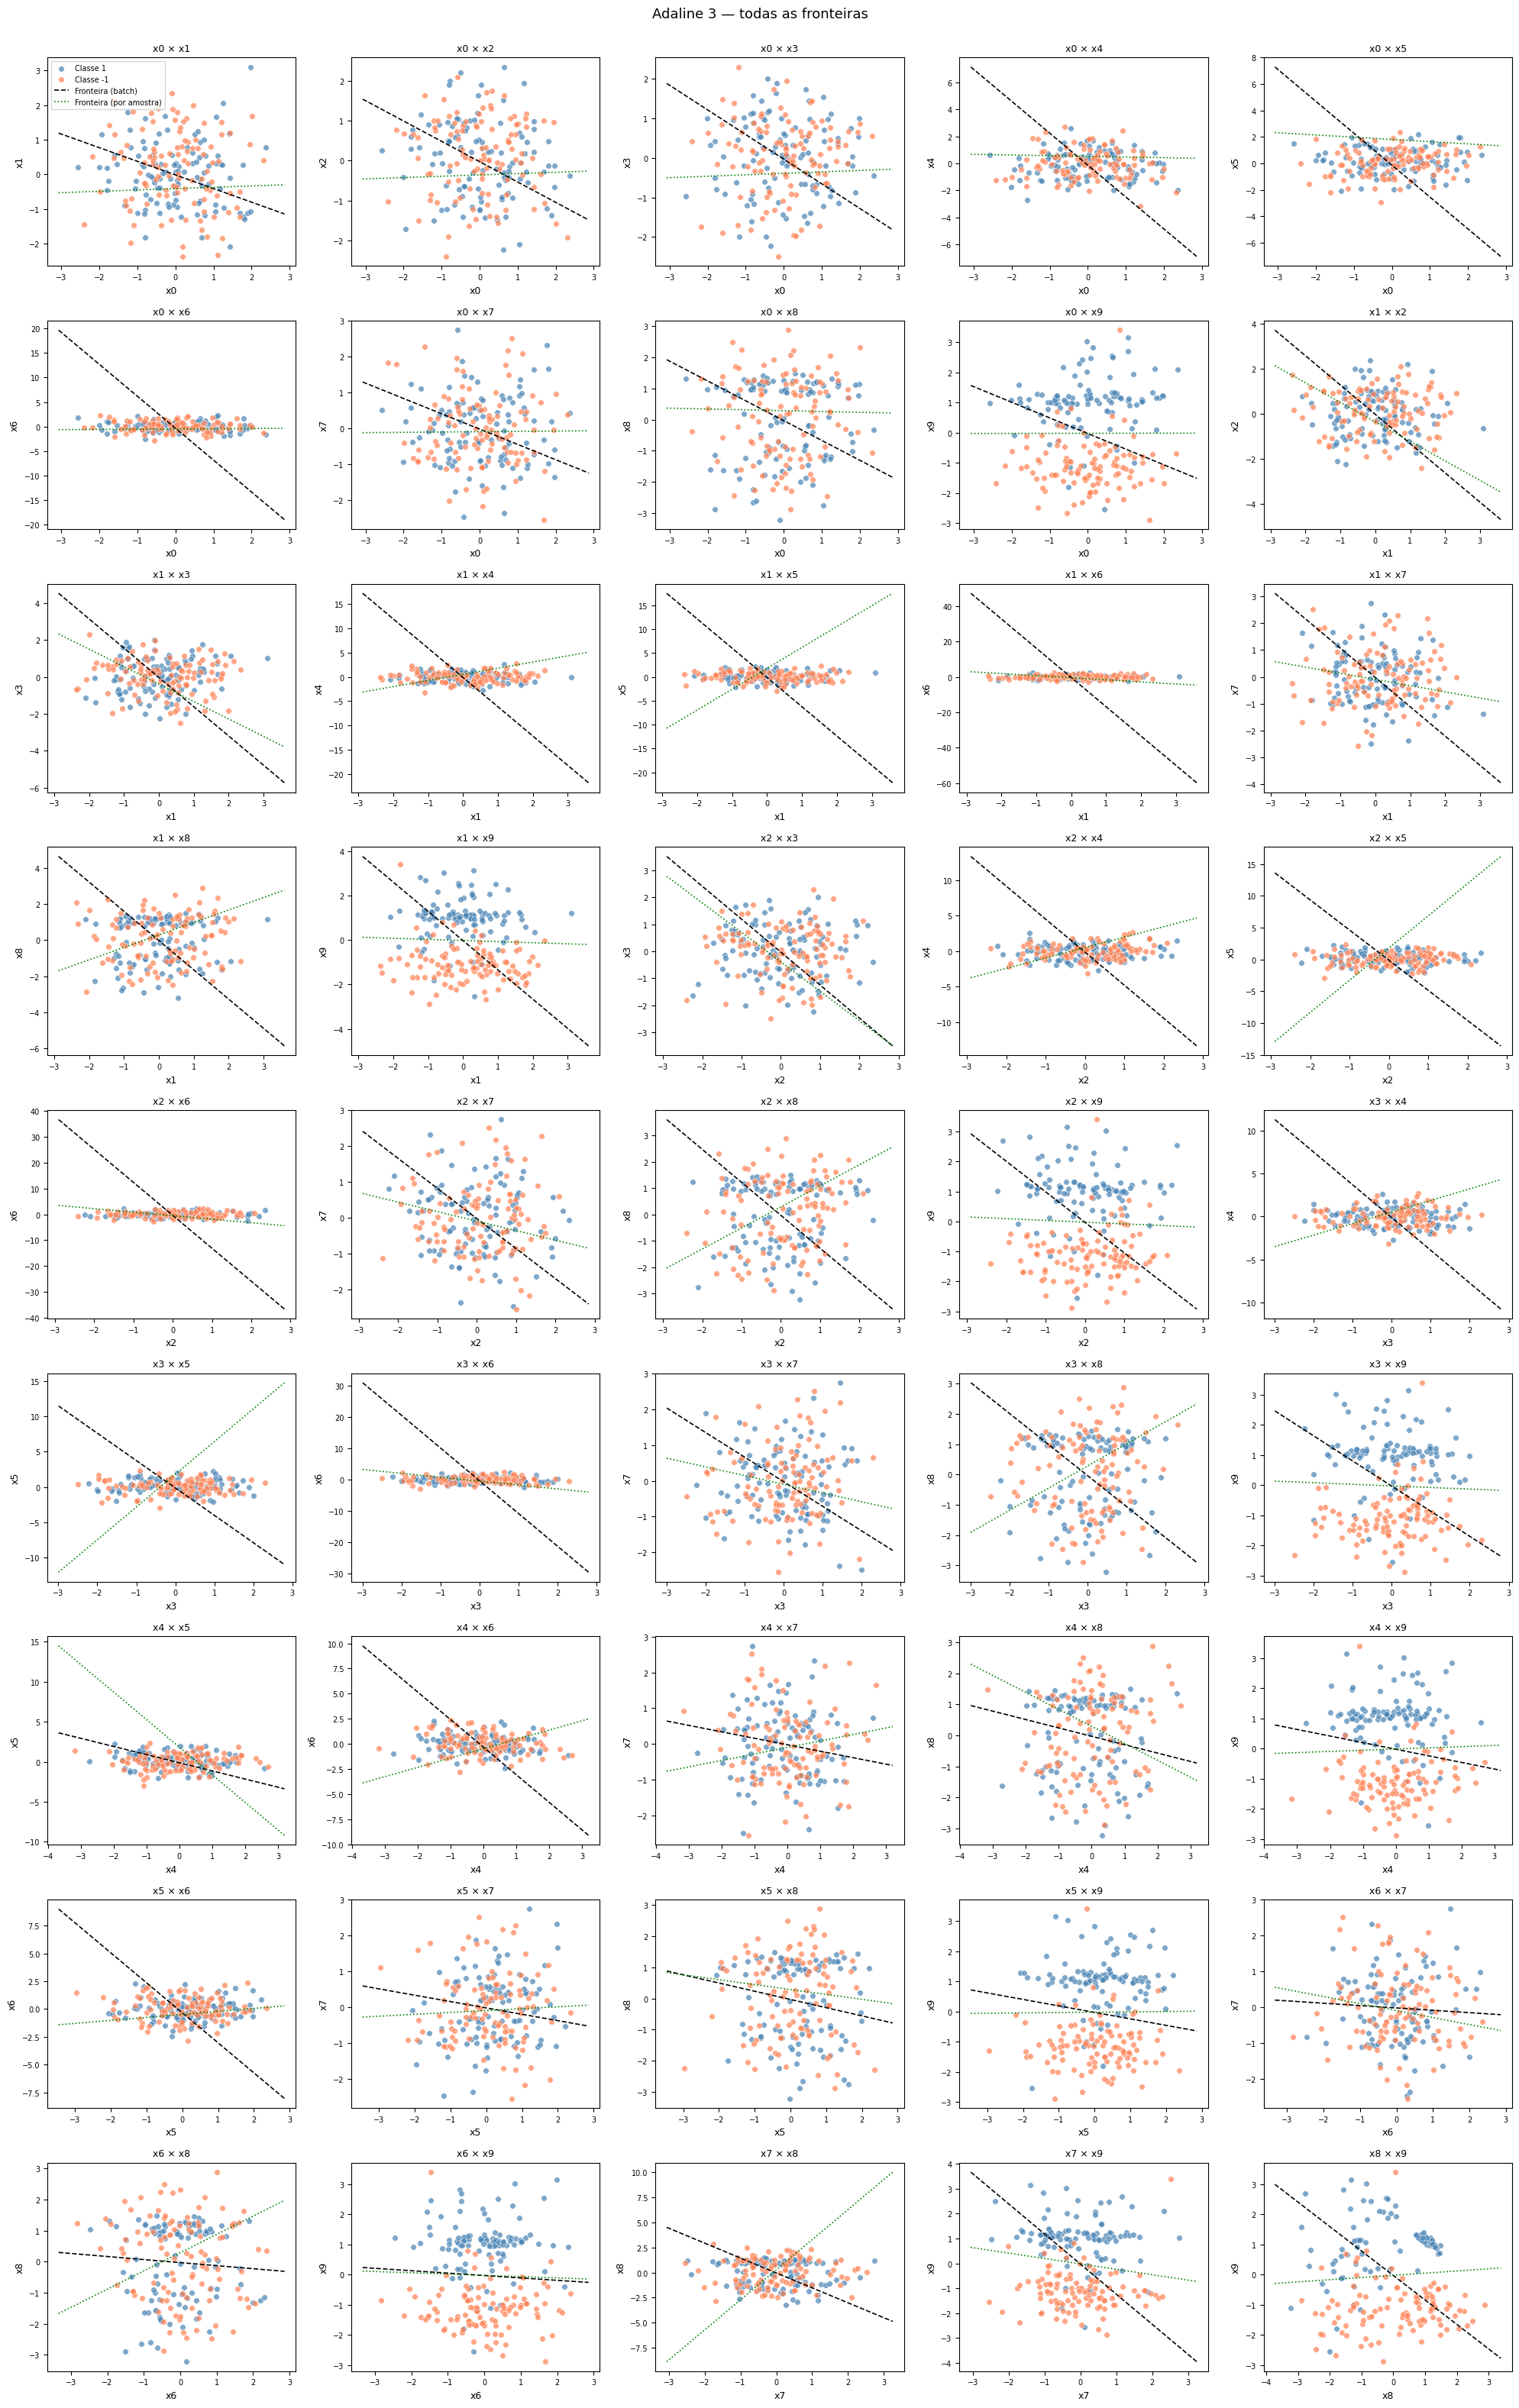

In [ ]:
X = np.append(X_train3.values, X_test3.values, axis=0)
y = np.append(y_train3.values, y_test3.values, axis=0)

plot_todas_fronteiras(
    X, y,
    w_amostra=adaline3.get_pesos(),
    w_batch=adaline_batch3.get_pesos(),
    feature_names=[f'x{i}' for i in range(10)],
    titulo_base='Adaline 3 — todas as fronteiras'
)